# Top Skills for Remote Roles

**Goal:** Identify which skills are most in-demand for remote data roles, and cross-reference demand with pay to highlight the most valuable skills to prioritize.

**Input:** `data_jobs_clean.parquet`, `data_jobs_salary.parquet`

**What this notebook covers:**
- Most in-demand skills for remote postings
- Demand vs salary — identifying high-value skills
- Key visualizations and takeaways

---

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

pd.options.display.float_format = '{:,.0f}'.format

def currency_formatter(x, pos):
    return f'${x/1000:,.0f}K'

def count_formatter(x, pos):
    return f'{x/1000:,.0f}K' if x >= 1000 else f'{x:.0f}'

df = pd.read_parquet('../data/clean/data_jobs_clean.parquet')
df_salary = pd.read_parquet('../data/clean/data_jobs_salary.parquet')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 785741 entries, 0 to 785740
Data columns (total 17 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   job_title_short        785741 non-null  object        
 1   job_title              785740 non-null  object        
 2   job_location           784696 non-null  object        
 3   job_via                785733 non-null  object        
 4   job_schedule_type      785741 non-null  object        
 5   job_work_from_home     785741 non-null  bool          
 6   search_location        785741 non-null  object        
 7   job_posted_date        785741 non-null  datetime64[ns]
 8   job_no_degree_mention  785741 non-null  bool          
 9   job_health_insurance   785741 non-null  bool          
 10  job_country            785692 non-null  object        
 11  salary_rate            33067 non-null   object        
 12  salary_year_avg        22003 non-null   floa

## Most In-Demand Skills for Remote Roles

In [5]:
df_remote = df[(df['job_work_from_home'] == True) & (df['job_skills'].notna())].copy()
df_remote_exploded = df_remote.explode('job_skills')

top_demand_skills = (
    df_remote_exploded['job_skills']
    .value_counts()
    .head(15)
)
top_demand_skills

job_skills
python        40492
sql           40249
aws           18274
azure         13907
spark         13049
tableau       11891
r             10686
excel          9341
java           8050
snowflake      7939
power bi       7657
airflow        7542
databricks     6941
gcp            6254
sas            6186
Name: count, dtype: int64

**Finding**: Python and SQL dominate remote job demand by a wide margin (40K+ postings each). Unlike the top-paying skills list, this ranking includes traditional BI tools (Tableau, Excel, Power BI) alongside cloud and data engineering tools (AWS, Azure, Spark, Snowflake, Airflow); confirming that demand and pay don't always align. This sets up the next step: identifying which skills offer the best combination of both.

### Cross-Referencing Demand and Salary
The most in-demand skills aren't necessarily the best-paid ones. Combining both metrics helps identify which skills offer the strongest overall value: high demand, high pay, or ideally both.

In [6]:
df_remote_salary = df_salary[
    (df_salary['job_work_from_home'] == True) & 
    (df_salary['job_skills'].notna())
].copy()
df_remote_salary = df_remote_salary.explode('job_skills')

skill_stats = (
    df_remote_salary.groupby('job_skills')['salary_year_avg']
    .agg(['median', 'count'])
    .rename(columns={'median': 'median_salary', 'count': 'salary_postings_count'})
)

demand_stats = df_remote_exploded['job_skills'].value_counts().rename('demand_count')

skill_combined = skill_stats.join(demand_stats, how='inner')
skill_combined = skill_combined[skill_combined['salary_postings_count'] >= 50]
skill_combined = skill_combined.sort_values('demand_count', ascending=False)
skill_combined.head(15)

,median_salary,salary_postings_count,demand_count
job_skills,,,
python,"135,000",2186,40492
sql,"127,390",2189,40249
aws,"140,000",892,18274
azure,"135,000",580,13907
spark,"141,511",585,13049
tableau,"115,000",733,11891
r,"126,577",790,10686
excel,"95,000",490,9341
java,"140,000",324,8050


### Visualizing Demand vs Salary

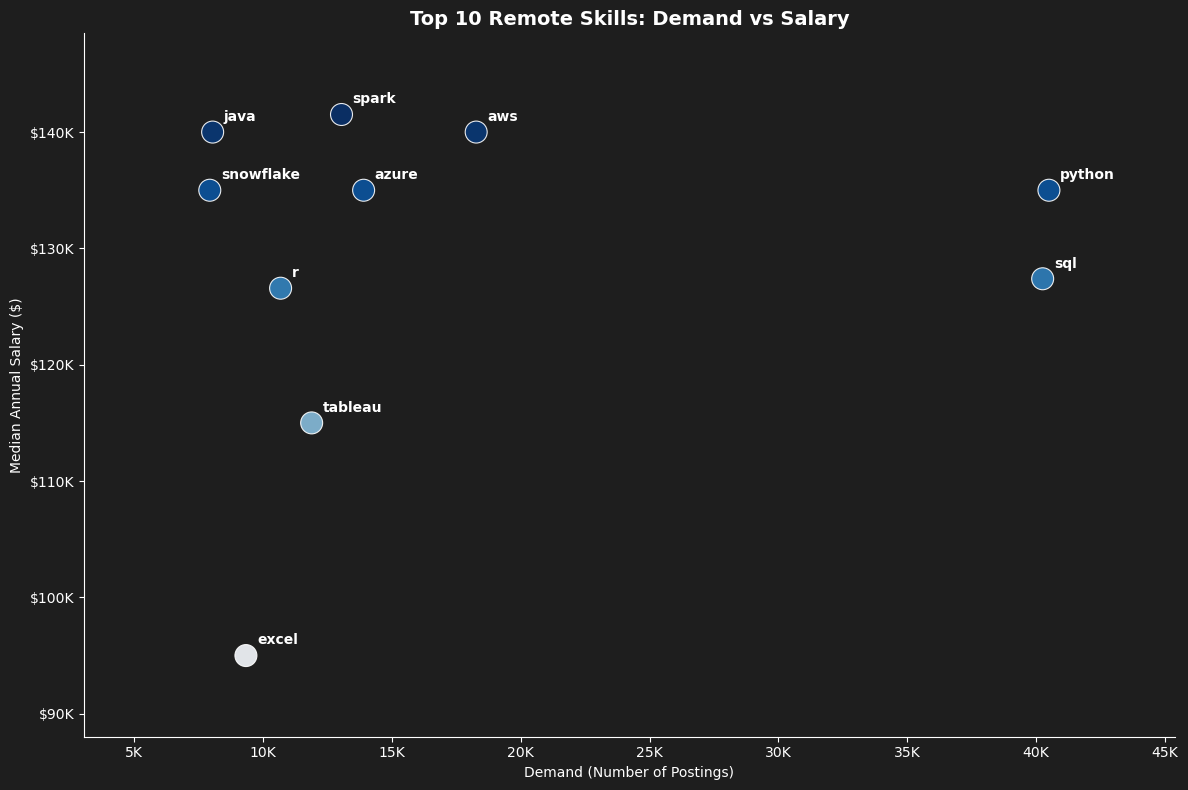

In [8]:
fig, ax = plt.subplots(figsize=(12, 8))
bg_color = '#1e1e1e'
fig.patch.set_facecolor(bg_color)
ax.set_facecolor(bg_color)

data = skill_combined.reset_index().sort_values('demand_count', ascending=False).head(10)

scatter = ax.scatter(
    data['demand_count'], 
    data['median_salary'], 
    s=250,  # fixed size, no more bubble-size clutter
    c=data['median_salary'], 
    cmap='Blues',
    alpha=0.9,
    edgecolors='white',
    linewidths=0.8
)

for _, row in data.iterrows():
    ax.annotate(
        row['job_skills'], 
        (row['demand_count'], row['median_salary']),
        textcoords="offset points", xytext=(8, 8),
        fontsize=10, color='white', weight='bold'
    )

ax.set_title('Top 10 Remote Skills: Demand vs Salary', fontsize=14, weight='bold', color='white')
ax.set_xlabel('Demand (Number of Postings)', color='white')
ax.set_ylabel('Median Annual Salary ($)', color='white')
ax.tick_params(colors='white')
ax.grid(False)
ax.spines[['top', 'right']].set_visible(False)
ax.spines[['left', 'bottom']].set_color('white')
ax.yaxis.set_major_formatter(FuncFormatter(currency_formatter))
ax.xaxis.set_major_formatter(FuncFormatter(count_formatter))

# Add breathing room around points
ax.margins(x=0.15, y=0.15)

plt.tight_layout()
plt.savefig('../images/demand_vs_salary_scatter.png', dpi=300, bbox_inches='tight', facecolor=bg_color)
plt.show()

**Finding**: Python stands out as the clearest "sweet spot" skill; combining the highest demand with a strong median salary. SQL follows a similar pattern but at a slightly lower salary. In contrast, skills like Spark, AWS, and Java show lower demand but rank among the highest-paying skills in the top 10, suggesting a smaller pool of postings but stronger compensation for those who have them. Meanwhile, traditional BI tools sit at the lower end of the salary axis despite still appearing among the most requested skills, reinforcing the demand-pay gap seen earlier.

**Takeaway**: Python is the safest, highest-leverage skill to prioritize; strong in both demand and pay. Beyond that, deepening skills in cloud/big data tools (Spark, AWS) offers a smaller but higher-paying niche worth targeting for differentiation.

## Summary

- Python and SQL dominate remote job demand by a wide margin (40K+ postings each), followed by a mix of cloud tools (AWS, Azure, GCP), BI tools (Tableau, Power BI, Excel), and data engineering tools (Spark, Airflow, Databricks, Snowflake).
- Demand and pay don't always align: traditional BI tools remain highly requested despite ranking among the lowest-paying skills, while some high-paying skills (like the top-paying ones from the salary notebook) don't appear among the most in-demand.
- Cross-referencing demand and salary among the top 10 most requested skills shows Python as the clearest "sweet spot": highest demand, combined with a strong median salary. SQL follows a similar but slightly lower-paying pattern.
- Spark, AWS, and Java show lower demand but rank among the highest-paying skills in this top 10, suggesting a smaller, more specialized pool of postings with stronger compensation.
- **Takeaway**: Python is the safest, highest-leverage skill to prioritize, given its balance of demand and pay. Deepening skills in cloud and big data tools (Spark, AWS) offers a smaller but higher-paying niche worth targeting for differentiation.